# Data Analysis

**Goal:** estimate how long a train trip will take as accurately as possible, given some real-world conditions

Travel time is influenced by:
- operational delay
- congestion
- weather

# Import Libraries

In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# **Import Data**

In [190]:
df = pd.read_csv("data/main_dataset.csv")

/var/folders/v6/lvzjzwnn7198jjy93qbh54gm0000gn/T/ipykernel_54227/1899251943.py:1: DtypeWarning: Columns (0: trip_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/main_dataset.csv")


In [191]:
print("Columns with negative values:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"{col}: {negative_count} negative values")

Columns with negative values:
latitude: 3989462 negative values
arrivalDelay: 1814174 negative values
departureDelay: 1414228 negative values
dwellTime_sec: 15 negative values
originLat: 3989556 negative values
destinationLat: 3989556 negative values
slowdown_lat: 1985294 negative values
temperature_2m: 1797980 negative values
apparent_temperature: 1814507 negative values
windspeed_10m: 2158493 negative values
windgusts_10m: 2238348 negative values
winddirection_10m: 2124080 negative values


# **Data Overview**



### Canberra Metro Light Rail Transit

In [192]:
stations = [
    {"name": "Gungahlin Place", "lat": -35.185639, "lon": 149.135481},
    {"name": "Manning Clark North", "lat": -35.1869861, "lon": 149.1433722},
    {"name": "Mapleton Avenue", "lat": -35.193389, "lon": 149.150972},
    {"name": "Nullarbor Avenue", "lat": -35.200556, "lon": 149.149305},
    {"name": "Well Station Drive", "lat": -35.2091361, "lon": 149.1472889},
    {"name": "Sandford Street", "lat": -35.221703, "lon": 149.144722},
    {"name": "EPIC & Racecourse", "lat": -35.228438, "lon": 149.143558},
    {"name": "Phillip Avenue", "lat": -35.235895, "lon": 149.143757},
    {"name": "Swinden Street", "lat": -35.2445364, "lon": 149.1344672},
    {"name": "Dickson Interchange", "lat": -35.2505862, "lon": 149.1336686},
    {"name": "Macarthur Avenue", "lat": -35.259988 , "lon": 149.132039},
    {"name": "Ipima Street", "lat": -35.265918, "lon": 149.131244},
    {"name": "Elouera Street", "lat": -35.272761, "lon": 149.130168},
    {"name": "Alinga Street", "lat": -35.277930, "lon": 149.129330}
]

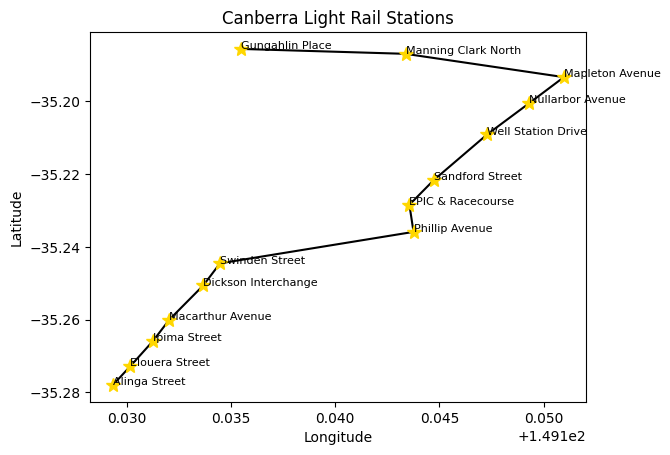

In [193]:
lats = [s["lat"] for s in stations]
lons = [s["lon"] for s in stations]
names = [s["name"] for s in stations]

plt.figure()
plt.plot(
    lons, lats,
    linestyle='-',
    marker='*',
    color='black',
    markerfacecolor='gold',
    markeredgecolor='gold',
    markersize=10
)

for i, name in enumerate(names):
    plt.text(lons[i], lats[i], name, fontsize=8)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Canberra Light Rail Stations")
plt.show()

## **Trip Identifiers**

| Feature               | Description                                                         |
|------------------------|---------------------------------------------------------------------|
| trip_id               | Unique identifier for each trip                                     |
| vehicle_id            | Unique identifier of the train                                      |
| vehicleLabel          | Label for the train (similar to a license plate)                    |
| vehicleLicencePlate   | Train license plate                                                  |
| trip_stop_sequence    | Sequence number indicating the stop order within a trip             |
| vehicle_stop_sequence | Sequence number indicating the stop order of the train within a trip|

## **Station Related**

| Feature               | Description                                                                 |
|------------------------|-----------------------------------------------------------------------------|
| originStopID          | ID of the current station (the station where the train came from)         |
| originStopName        | Name of the current station (the station where the train came from)       |
| originLat             | Latitude of the current station (the station where the train came from)   |
| originLon             | Longitude of the current station (the station where the train came from)  |
| destinationStopID     | ID of the next station (the station where the train will go to)           |
| destinationStopName   | Name of the next station (the station where the train will go to)         |
| destinationLat        | Latitude of the next station (the station where the train will go to)     |
| destinationLon        | Longitude of the next station (the station where the train will go to)    |

## **Operational Features**

| Feature                  | Description |
|---------------------------|-------------|
| speed_kph                | Speed of the train in km/h (derived by multiplying `speed_mps` by 3.6). |
| speed_mps                | Speed of the train in m/s (derived from `distance_m / delta_t_sec`). |
| distance_m               | Segment-level distance between consecutive records (derived from `current odometer − previous odometer`). |
| delta_t_sec              | Time difference in seconds between the current and previous timestamp. |
| travel_time_sec          | Elapsed travel time from departure to the current timestamp (`current timestamp − departureTime`). |
| dwellTime_sec            | Time in seconds the train spent at a stop (derived from `departureTime − arrivalTime`). |
| total_travel_time_sec    | Total travel time of a trip (aggregated sum of segment travel times within a trip). |
| total_distance_m         | Total distance of a trip (aggregated sum of segment distances within a trip). |
| congestionLevel          | Congestion status of trains (0 = unknown, 1 = running smoothly, 2 = stop-and-go, 3 = congestion, 4 = severe congestion). |
| odometer                 | Cumulative distance traveled by the train. |
| bearing                  | Compass bearing (direction) toward the next stop or intermediate location. |


*NOTE: 

- Positive dwell time (>0) → vehicle stopped at the station before leaving

- Zero dwell time (=0) → vehicle departed immediately

- Negative dwell time (<0) → departure was recorded earlier than arrival

## **Weather-Related Features**

| Feature                | Description |
|------------------------|-------------|
| temperature_2m        | Air temperature measured 2 meters above ground level. |
| apparent_temperature  | “Feels-like” temperature that accounts for humidity, wind, and other atmospheric conditions. |
| precipitation         | Total hourly precipitation (combined rain, snow, etc.). |
| rain                  | Total hourly rainfall. |
| snowfall              | Total hourly snowfall. |
| windspeed_10m         | Wind speed measured 10 meters above ground level. |
| windgusts_10m         | Maximum wind gust speed measured at 10 meters above ground. |
| winddirection_10m     | Dominant wind direction at 10 meters above ground |


*NOTE: 

*NEGATIVE VALUES FOR THESE ARE VALID BECAUSE THEY'RE ALREADY NORMALIZED*

temperature_2m, apparent_temperature

- Negative → colder than average
- Positive → warmer than average

windspeed_10m, windgusts_10m

- Negative → slower-than-average wind
- Positive → faster-than-average wind

winddirection_10m

- negatives just mean “direction below the mean angle"


## **Slowdown-Related Features**

| Feature         | Description |
|----------------|-------------|
| is_slow_speed  | Binary indicator for slow speed (1 = slow speed, 0 = not slow). |
| is_long_dwell  | Binary indicator for long dwell time at a stop (1 = long dwell, 0 = not). |
| is_delayed     | Binary indicator for delay (1 = delayed, 0 = not delayed). |
| is_congested   | Binary indicator for congestion (1 = congested, 0 = not congested). |
| is_slowdown    | Binary indicator for slowdown event (1 = slowdown, 0 = not slowdown). |
| slowdown_lat   | Latitude where the slowdown event occurred. |
| slowdown_lon   | Longitude where the slowdown event occurred. |
| segment        | Route segment where the slowdown occurred (origin station – destination station). |

## **Other Features**


| Feature                  | Description |
|---------------------------|-------------|
| currentLoc               | Current location of the train (geospatial point). |
| timestamp                | Recorded timestamp of the current train position. |
| latitude                 | Current latitude of the train (expanded from geospatial data). |
| longitude                | Current longitude of the train (expanded from geospatial data). |
| currentStatus            | Operational status of the train (0 = stopped at, 1 = in transit to, 2 = incoming at). |
| is_weekend               | Binary indicator if the trip occurs on a weekend (1 = weekend, 0 = weekday). |
| arrivalDelay             | Difference in seconds between scheduled and actual arrival time (negative = early arrival). |
| arrivalTime              | Actual arrival time of the train. |
| departureDelay           | Difference in seconds between scheduled and actual departure time (negative = early departure). |
| departureTime            | Actual departure time of the train. |
| tripScheduleRelationship | Indicates the status of the scheduled trip (0 = no data, 1 = scheduled, 2 = skipped). |
| is_peak_hour             | Binary indicator if the trip falls within peak hours (1 = peak hour, 0 = not peak hour). |
| has_prev_stop            | Binary indicator if the trip has a previous stop (1 = has previous stop, 0 = none). |
| service_date             | Service day of the trip (derived using GTFS-style cutoff to handle late-night operations). |

# **Dataset Description**

In [194]:
df.shape

(3989556, 55)

*Interpretation:*

There are about 4 million rows or 3,890,556 rows to be exact and 55 columns

In [195]:
df[['trip_id','originStopName', 'destinationStopName']].nunique()

trip_id                4071
originStopName           24
destinationStopName      26
dtype: int64

*Interpretation:*

trip_id → 4,071 unique values
- dataset contains 4,071 distinct trips.
- *this means:* Each trip has many timestamp records.

There are 24 unique origin stations in the dataset.

There are 26 unique destination stations.

In [196]:
df['timestamp'].min(), df['timestamp'].max()

('2021-09-01 00:02:45', '2022-09-01 23:54:15')

*Interpretation*

**Start:** September 1, 2021 at 00:02:45

**End:** September 1, 2022 at 23:54:15

# **Basic Statistical Summary**

In [197]:
num_cols = [
    'arrivalDelay', 'departureDelay','distance_m','delta_t_sec','speed_kph', 'speed_mps',
    'travel_time_sec','dwellTime_sec',
    'total_travel_time_sec','total_distance_m'
]

df[num_cols].describe()

,arrivalDelay,departureDelay,distance_m,delta_t_sec,speed_kph,speed_mps,travel_time_sec,dwellTime_sec,total_travel_time_sec,total_distance_m
count,3.989258e+06,3.989257e+06,3.989556e+06,3.989556e+06,3.989556e+06,3.989556e+06,3.989556e+06,3.989556e+06,3.989556e+06,3.989556e+06
mean,5.544493e+00,1.187382e+01,1.886081e+02,2.237562e+01,3.037804e+01,8.438343e+00,6.142413e+01,2.630804e+01,3.499172e+02,9.684839e+02
std,3.390181e+01,3.424614e+01,2.236441e+02,2.197503e+01,2.086576e+01,5.796044e+00,5.667605e+01,4.478511e+01,1.863269e+02,3.861107e+02
min,-3.540000e+02,-3.720000e+02,0.000000e+00,9.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-8.635200e+04,0.000000e+00,0.000000e+00
25%,-1.600000e+01,-9.000000e+00,6.500000e+01,1.500000e+01,1.176000e+01,3.266667e+00,3.100000e+01,2.200000e+01,2.350000e+02,7.660000e+02
50%,2.000000e+00,8.000000e+00,1.650000e+02,1.500000e+01,2.928000e+01,8.133333e+00,5.900000e+01,2.600000e+01,3.240000e+02,8.950000e+02
75%,2.200000e+01,2.900000e+01,2.600000e+02,3.000000e+01,4.908000e+01,1.363333e+01,8.700000e+01,2.900000e+01,4.260000e+02,1.208000e+03
max,8.780000e+02,8.860000e+02,1.181400e+04,1.770000e+03,7.997143e+01,2.221429e+01,8.636400e+04,6.610000e+02,8.636400e+04,1.186100e+04


### ***Interpretation***

#### **arrivalDelay**

Mean: 5.54 seconds

Median: 2 seconds

25th–75th percentile: -16 to 22 seconds

Minimum: -354 seconds (~6 minutes early)

Maximum: 878 seconds (~14.6 minutes late)


Most trains arrive close to their scheduled time, with a median delay of only 2 seconds. The interquartile range suggests that most arrivals occur within ±20 seconds of schedule, indicating relatively stable operations. Negative values represent early arrivals, while the extreme positive values indicate occasional significant delays.

#### **departureDelay**

Mean: 11.87 seconds

Median: 8 seconds

25th–75th percentile: -9 to 29 seconds

Minimum: -372 seconds (~6.2 minutes early)

Maximum: 886 seconds (~14.8 minutes late)


Departure delays are slightly larger than arrival delays, suggesting that trains may accumulate small delays while boarding passengers or waiting at stations. However, the median delay remains relatively small, indicating generally punctual departures.

#### **distance_m**

Mean: 188.61 m

Median: 165 m

Typical range (IQR): 65–260 m

Maximum: 11,814 m


Most movement segments represent short distances between sequential GPS readings or station segments. Large maximum values likely correspond to longer movements between stations or aggregated travel segments.

#### **delta_t_sec**

Mean: 22.38 seconds

Median: 15 seconds

Maximum: 1,770 seconds (~29 minutes)

The dataset records train positions roughly every 15–30 seconds, indicating high-frequency monitoring of train movements. Large time gaps may represent operational pauses, long dwell times, or missing intermediate records.

#### **speed**

*speed_kph*

Mean: 30.38 km/h

Median: 29.28 km/h

Maximum: 79.97 km/h

*speed_mps*

Mean: 8.44 m/s

Median: 8.13 m/s

Maximum: 22.21 m/s

Both metrics indicate that trains typically operate at around 30 km/h (8.4 m/s), which is consistent with typical light rail operating speeds. Zero speeds correspond to stationary periods such as station stops

#### **travel_time_sec**

Mean: 61.42 seconds

Median: 59 seconds

Maximum: 86,364 seconds (~24 hours)

Most segment travel times are around one minute, reflecting movement between consecutive recorded positions. Extremely large maximum values likely represent edge cases or anomalies in the dataset.

#### **dwellTime_sec**

Mean: 26.31 seconds

Median: 26 seconds

Typical range: 22–29 seconds

Minimum: -86,352 seconds (timestamp inconsistency)


Station stops are relatively consistent, typically lasting around 25–30 seconds. The extreme negative value suggests inconsistencies in arrival and departure timestamps, likely due to service-day transitions or data irregularities.

#### **total_travel_time_sec**

Mean: 349.92 seconds (~5.8 minutes)

Median: 324 seconds

Maximum: 86,364 seconds

#### **total_distance_m**

Mean: 968.48 m

Median: 895 m

Maximum: 11,861 m


Trips typically cover approximately 1 kilometer and take about 5–6 minutes on average. The right-skewed distribution indicates that some trips are longer due to extended routes or operational variations.

# **Exploratory Data Analysis**

In [48]:
df['has_rain'] = df['rain'] > 0
df.groupby('has_rain')['speed_mps'].mean()

has_rain
False    8.442538
True     8.422456
Name: speed_mps, dtype: float64

**Interpretation**

The results compare the average vehicle speed (in meters per second) during rainy and non-rainy conditions. When no rain is present, the mean speed is 8.44 m/s, while during rainy conditions, the mean speed is 8.42 m/s.

The difference between the two values is very small (approximately 0.02 m/s), indicating that rain has minimal impact on the average speed of the transit vehicles in the dataset. This suggests that the transit system maintains relatively consistent speeds even during rainfall.

Overall, the results imply that rain does not significantly affect vehicle speed, likely because the transit system operates on dedicated rail infrastructure or controlled routes, where weather conditions such as light to moderate rain have limited influence on operational speed.

In [198]:
df[['speed_mps','precipitation','windspeed_10m','temperature_2m', 'rain', 'snowfall']].corr()

,speed_mps,precipitation,windspeed_10m,temperature_2m,rain,snowfall
speed_mps,1.000000,-0.002053,0.008079,-0.003733,-0.002047,-0.000900
precipitation,-0.002053,1.000000,0.075303,0.047665,0.999961,0.073752
windspeed_10m,0.008079,0.075303,1.000000,-0.007150,0.075042,0.028565
temperature_2m,-0.003733,0.047665,-0.007150,1.000000,0.047939,-0.027880
rain,-0.002047,0.999961,0.075042,0.047939,1.000000,0.065210
snowfall,-0.000900,0.073752,0.028565,-0.027880,0.065210,1.000000


**Interpretation**

The correlation matrix examines the relationship between vehicle speed (speed_mps) and various weather variables, including precipitation, wind speed, temperature, rain, and snowfall.

The results show that vehicle speed has extremely weak correlations with all weather variables. The correlation between speed and precipitation (-0.0021) and speed and rain (-0.0020) is nearly zero, indicating that rainfall has virtually no linear relationship with vehicle speed. Similarly, snowfall (-0.0009) also shows an almost negligible relationship with speed.

Wind speed (windspeed_10m) has a very small positive correlation with speed (0.0081), while temperature (temperature_2m) shows a slight negative correlation (-0.0037). However, these values are extremely close to zero, suggesting that weather conditions have minimal direct influence on vehicle speed in this dataset.

It is also notable that precipitation and rain have an almost perfect correlation (0.999961), indicating that these variables essentially represent the same measurement in the dataset.

Overall, the results suggest that vehicle speed remains relatively stable regardless of weather conditions, which may be attributed to the transit system operating on dedicated infrastructure and controlled schedules. Although simple correlation shows weak relationships, weather variables may still contribute to nonlinear effects or indirect impacts on travel time, which can be captured by more advanced predictive models.

In [44]:
df.groupby('trip_id')['total_travel_time_sec'].max().describe()

count     4071.000000
mean       980.212479
std       1426.667268
min         42.000000
25%        612.000000
50%        813.000000
75%       1180.000000
max      86364.000000
Name: total_travel_time_sec, dtype: float64

**Interpretation**

The descriptive statistics summarize the distribution of total travel time per trip in seconds across 4,071 trips. The average total travel time is 980.21 seconds (approximately 16.3 minutes), while the median is 813 seconds (about 13.6 minutes). The fact that the mean is higher than the median suggests that the distribution is right-skewed, meaning that a small number of trips with very long travel times increase the overall average.

The standard deviation of 1426.67 seconds indicates a high level of variability in total travel times across trips. Most trips fall within a smaller range, as shown by the interquartile range, where 25% of trips take less than 612 seconds (~10.2 minutes) and 75% take less than 1180 seconds (~19.7 minutes).

The minimum travel time is 42 seconds, which likely represents very short trips or partial trip observations. On the other hand, the maximum travel time reaches 86,364 seconds (approximately 24 hours), which is extremely large compared to the typical values. This suggests the presence of outliers or irregular records, possibly caused by incomplete trips, logging issues, or extended inactive periods in the dataset.

Overall, the statistics indicate that most trips fall within a reasonable travel time range, but the dataset contains extreme outliers that significantly increase the overall variance, which should be considered during data preprocessing and modeling.

In [45]:
df.groupby('trip_id')['total_distance_m'].max().describe()

count     4071.000000
mean      2934.133382
std       2539.331722
min        194.000000
25%       1432.000000
50%       1485.000000
75%       3723.500000
max      11861.000000
Name: total_distance_m, dtype: float64

**Interpretation**

The descriptive statistics summarize the distribution of total travel distance per trip across 4,071 trips. On average, trips cover a distance of 2934.13 meters (approximately 2.93 km). However, the median distance is 1485 meters (~1.49 km), which is considerably lower than the mean. This difference suggests that the distribution of trip distances is right-skewed, where a number of longer trips increase the overall average.

The standard deviation of 2539.33 meters indicates substantial variability in trip distances. Based on the quartile values, 25% of trips cover less than 1432 meters, while 75% of trips cover less than 3723.5 meters, meaning that most trips fall roughly between 1.4 km and 3.7 km.

The minimum trip distance is 194 meters, which likely represents very short segments or partial trip records. In contrast, the maximum distance reaches 11,861 meters (~11.9 km), indicating that some trips cover significantly longer distances across the transit network.

Overall, these results suggest that while most trips occur within moderate distances, the presence of longer trips increases the overall mean and variability. This variation reflects the structure of the transit network, where trips may span different numbers of stations or segments, resulting in varying total travel distances.

In [199]:
df[['speed_kph','speed_mps','total_travel_time_sec']].corr()

,speed_kph,speed_mps,total_travel_time_sec
speed_kph,1.000000,1.000000,-0.114646
speed_mps,1.000000,1.000000,-0.114646
total_travel_time_sec,-0.114646,-0.114646,1.000000


**Interpretation**

The correlation matrix shows the relationship between vehicle speed and total travel time. As expected, speed in kilometers per hour (speed_kph) and speed in meters per second (speed_mps) have a perfect correlation of 1.0, since they represent the same variable expressed in different units.

Both speed measures show a weak negative correlation with total travel time (-0.1146). This indicates that higher vehicle speeds are generally associated with shorter travel times, which aligns with expected transit behavior. However, the correlation is relatively small in magnitude, suggesting that speed alone does not strongly determine total travel time.

This weak relationship may occur because total travel time is influenced by several other factors beyond movement speed, such as station dwell times, passenger boarding and alighting, operational scheduling, and possible delays. As a result, even when vehicles move faster between segments, the overall trip duration may still vary due to these additional operational factors.

Overall, the results suggest that while speed contributes to travel time variations, it is not the sole determinant, highlighting the importance of incorporating multiple features in predictive models for transit travel time estimation.

In [200]:
df.groupby("is_long_dwell")["total_travel_time_sec"].agg(["count","mean","median","std"])

,count,mean,median,std
is_long_dwell,,,,
0,3917643,349.155290,321.0,186.731618
1,71913,391.425723,384.0,157.281789


**Interpretation**

The statistics compare total travel time between trips with normal dwell times and those with long dwell events. Trips without long dwell events (is_long_dwell = 0) represent the majority of the dataset with 3,917,643 observations. These trips have an average travel time of 349.16 seconds and a median of 321 seconds, with a standard deviation of 186.73 seconds, indicating moderate variability in travel durations.

In contrast, trips that include long dwell events (is_long_dwell = 1) account for a much smaller portion of the dataset with 71,913 observations. These trips have a higher mean travel time of 391.43 seconds and a median of 384 seconds, suggesting that longer station dwell times contribute to increased total travel durations. The standard deviation of 157.28 seconds indicates slightly lower variability compared to the normal dwell group.

Overall, the results suggest that long dwell events are associated with longer total travel times, which is expected since extended stops at stations increase the overall duration of a trip. This highlights the importance of considering dwell-time-related features when modeling transit travel time, as station-level delays can significantly influence overall trip performance.

In [201]:
df.groupby("is_slow_speed")["total_travel_time_sec"].agg(["count","mean","median","std"])

,count,mean,median,std
is_slow_speed,,,,
0,2208935,330.758208,315.0,157.374632
1,1780621,373.684796,336.0,214.574000


**Interpretation**

The statistics compare total travel time between trips with normal speeds and those experiencing slow-speed conditions. Trips without slow-speed events (is_slow_speed = 0) account for 2,208,935 observations and have an average travel time of 330.76 seconds, with a median of 315 seconds and a standard deviation of 157.37 seconds, indicating relatively shorter and more consistent travel durations.

In contrast, trips classified as slow-speed events (is_slow_speed = 1) include 1,780,621 observations and show a higher mean travel time of 373.68 seconds and a median of 336 seconds. The standard deviation is also significantly higher (214.57 seconds), indicating that trips with slow-speed conditions tend to be longer and more variable.

Overall, the results suggest that slow-speed conditions are associated with increased travel time and greater variability in trip duration. This indicates that when vehicles operate below normal speeds—possibly due to congestion, operational constraints, or track conditions—the total travel time tends to increase. These findings highlight the importance of incorporating speed-related indicators in travel time prediction models to capture variations caused by slow-moving segments.

In [202]:
df.groupby("is_congested")["total_travel_time_sec"].agg(["count","mean","median","std"])

,count,mean,median,std
is_congested,,,,
0,3989556,349.917228,324.0,186.326866


**Interpretation**

The statistics show that all observations fall under non-congested conditions (is_congested = 0), with a total of 3,989,556 records. Under these conditions, the average total travel time is 349.92 seconds, with a median of 324 seconds. The standard deviation of 186.33 seconds indicates moderate variability in travel times across trips.

Since there are no observations labeled as congested, it suggests that congestion is either not present in the dataset or not detected based on the defined congestion criteria. This is likely because the transit system operates on dedicated rail infrastructure, where vehicles are generally less affected by road traffic congestion compared to bus or mixed-traffic systems.

Overall, the results indicate that travel time variations in the dataset are not driven by congestion, and other operational factors such as dwell times, speed variations, delays, or service schedules may play a more significant role in influencing total travel time.

In [203]:
df.groupby("is_delayed")["total_travel_time_sec"].agg(["count","mean","median","std"])

,count,mean,median,std
is_delayed,,,,
0,3696894,351.301954,324.0,188.106737
1,292662,332.425433,311.0,161.149375


**Interpretation**

The statistics compare total travel time between trips with and without delay events. Trips without delays (is_delayed = 0) make up the majority of the dataset with 3,696,894 observations. These trips have an average travel time of 351.30 seconds and a median of 324 seconds, with a standard deviation of 188.11 seconds, indicating moderate variability in trip durations.

In contrast, trips labeled as delayed (is_delayed = 1) account for 292,662 observations and show a lower mean travel time of 332.43 seconds and a median of 311 seconds. The standard deviation is also lower (161.15 seconds) compared to the non-delayed group.

Interestingly, delayed trips do not necessarily correspond to longer total travel times. This may occur because the delay indicator reflects schedule deviation rather than the actual movement time between stations. For example, a vehicle may be classified as delayed relative to the schedule but still travel between stations at normal speeds once it departs.

Overall, the results suggest that schedule-based delays do not always translate into longer segment travel times, indicating that delays may be influenced more by station dwell times, scheduling gaps, or operational timing differences rather than slower vehicle movement.

In [204]:
df.groupby("is_slowdown")["total_travel_time_sec"].agg(["count","mean","median","std"])

,count,mean,median,std
is_slowdown,,,,
0,2004202,330.561539,312.0,159.670314
1,1985354,369.456671,335.0,208.010529


**Interpretation**

The statistics compare total travel time between trips with and without slowdown events. Trips without slowdown conditions (is_slowdown = 0) consist of 2,004,202 observations and have an average travel time of 330.56 seconds with a median of 312 seconds. The standard deviation of 159.67 seconds indicates relatively moderate variability in travel times under normal operating conditions.

In contrast, trips that experience slowdown events (is_slowdown = 1) include 1,985,354 observations and show a higher mean travel time of 369.46 seconds and a median of 335 seconds. The standard deviation is also higher (208.01 seconds), suggesting greater variability in trip durations when slowdowns occur.

Overall, these results indicate that slowdown events are associated with longer and more variable travel times. This suggests that reduced vehicle speeds possibly due to operational constraints, temporary disruptions, or traffic interactions can significantly impact overall trip duration. These findings highlight the importance of incorporating slowdown-related indicators in travel time prediction models to better capture variations in transit performance.

#### **Group Analysis**

In [ ]:
cols_needed = [
    "total_travel_time_sec", "is_peak_hour", "is_weekend", "segment",
    "temperature_2m", "rain", "precipitation", "windspeed_10m",
    "arrivalDelay", "departureDelay"
]
missing = [c for c in cols_needed if c not in df.columns]
print("Missing columns:", missing if missing else "None")

Missing columns: None


#### **Peak vs Off-Peak**

In [206]:
eda = df.copy()

# Keep only rows with valid travel time
eda = eda[eda["total_travel_time_sec"].notna()].copy()

# Remove invalid travel times (negative or above 24 hours)
eda = eda[
    (eda["total_travel_time_sec"] >= 0) &
    (eda["total_travel_time_sec"] < 86364.0)
].copy()

print(eda.shape)

(3989555, 55)


In [207]:
peak_summary = (
    eda.groupby("is_peak_hour")["total_travel_time_sec"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .rename(index={0: "Off-Peak", 1: "Peak"})
)

peak_summary

,count,mean,median,std,min,max
is_peak_hour,,,,,,
Off-Peak,2937009,355.664561,327.0,186.434231,0.0,2909.0
Peak,1052546,333.798235,311.0,165.000056,0.0,2466.0


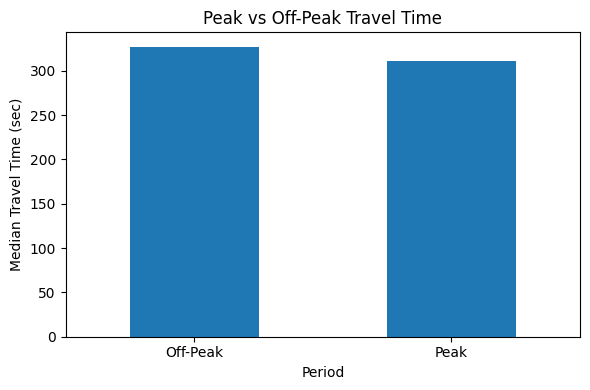

In [208]:
peak_plot = (
    eda.groupby("is_peak_hour")["total_travel_time_sec"]
    .median()
    .rename(index={0: "Off-Peak", 1: "Peak"})
)

plt.figure(figsize=(6,4))
peak_plot.plot(kind="bar")
plt.ylabel("Median Travel Time (sec)")
plt.xlabel("Period")
plt.title("Peak vs Off-Peak Travel Time")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation**

The descriptive statistics indicate differences in total travel time between peak and off-peak periods. During off-peak hours, the mean total travel time is 355.66 seconds, with a median of 327 seconds and a standard deviation of 186.43 seconds. This suggests that trips during off-peak periods tend to take slightly longer and exhibit greater variability.

In contrast, during peak hours, the mean total travel time is 333.80 seconds, with a median of 311 seconds and a lower standard deviation of 165.00 seconds. These values indicate that trips during peak periods are generally shorter and more consistent compared to off-peak periods.

The maximum travel time is also higher during off-peak hours (2909 seconds) compared to peak hours (2466 seconds), suggesting that extreme travel times or irregular trips are more likely to occur outside peak periods.

Overall, the results suggest that peak-hour operations appear more stable and slightly faster, which may be attributed to higher service frequency and more structured scheduling during busy periods, while off-peak operations may experience slightly longer and more variable travel times due to reduced service frequency or operational gaps.

#### **Weekday vs Weekend**

In [209]:
weekend_summary = (
    eda.groupby("is_weekend")["total_travel_time_sec"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .rename(index={0: "Weekday", 1: "Weekend"})
)

weekend_summary

,count,mean,median,std,min,max
is_weekend,,,,,,
Weekday,3132968,344.155792,318.0,177.227071,0.0,2909.0
Weekend,856587,370.889275,343.0,193.957318,0.0,2628.0


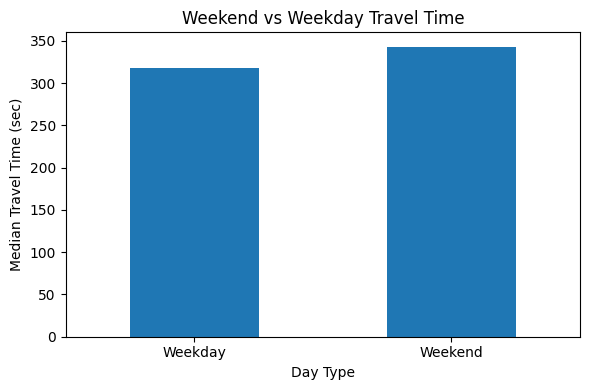

In [210]:
weekend_plot = (
    eda.groupby("is_weekend")["total_travel_time_sec"]
    .median()
    .rename(index={0: "Weekday", 1: "Weekend"})
)

plt.figure(figsize=(6,4))
weekend_plot.plot(kind="bar")
plt.ylabel("Median Travel Time (sec)")
plt.xlabel("Day Type")
plt.title("Weekend vs Weekday Travel Time")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation**

The statistics show a noticeable difference in total travel time between weekdays and weekends. On weekdays, the mean total travel time is 344.16 seconds, with a median of 318 seconds, indicating that most trips are completed within roughly 5–6 minutes. The standard deviation of 177.23 seconds suggests moderate variability in travel times during weekdays.

On weekends, the average travel time increases to 370.89 seconds, with a median of 343 seconds. The higher mean and median values indicate that trips tend to take slightly longer on weekends compared to weekdays. Additionally, the standard deviation is 193.96 seconds, which is higher than that of weekdays, suggesting greater variability in travel times during weekends.

The maximum travel time is slightly higher on weekdays (2909 seconds) compared to weekends (2628 seconds), indicating that extreme delays or unusually long trips occasionally occur during weekday operations.

Overall, these results suggest that weekend trips tend to have slightly longer and more variable travel times, which may be influenced by factors such as different service frequencies, operational schedules, or passenger demand patterns compared to weekday operations.

#### **Segment**

In [211]:
segment_summary = (
    eda.groupby("segment")["total_travel_time_sec"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median", ascending=False)
)

segment_summary.head(15)

,count,mean,median,std
segment,,,,
EPIC and Racecourse Platform 2 → Well Station Drive Platform 2,2871,1918.829676,1959.0,364.909772
Well Station Drive Platform 1 → EPIC and Racecourse Platform 1,1908,1476.653564,1383.0,372.420480
EPIC and Racecourse Platform 2 → Sandford Street Platform 2,176168,648.427490,606.0,236.197252
Well Station Drive Platform 1 → Sandford Street Platform 1,64012,457.919859,446.0,148.179844
Macarthur Avenue Platform 2 → Dickson Platform 2,87584,440.692912,435.0,115.417137
Sandford Street Platform 2 → Well Station Drive Platform 2,82124,443.999830,432.0,145.506115
EPIC and Racecourse Platform 1 → Phillip Avenue Platform 1,105196,410.390214,402.0,125.475511
Dickson Platform 1 → Macarthur Avenue Platform 1,110076,409.598623,396.0,130.781740
Phillip Avenue Platform 2 → EPIC and Racecourse Platform 2,98642,390.725654,384.0,127.545764


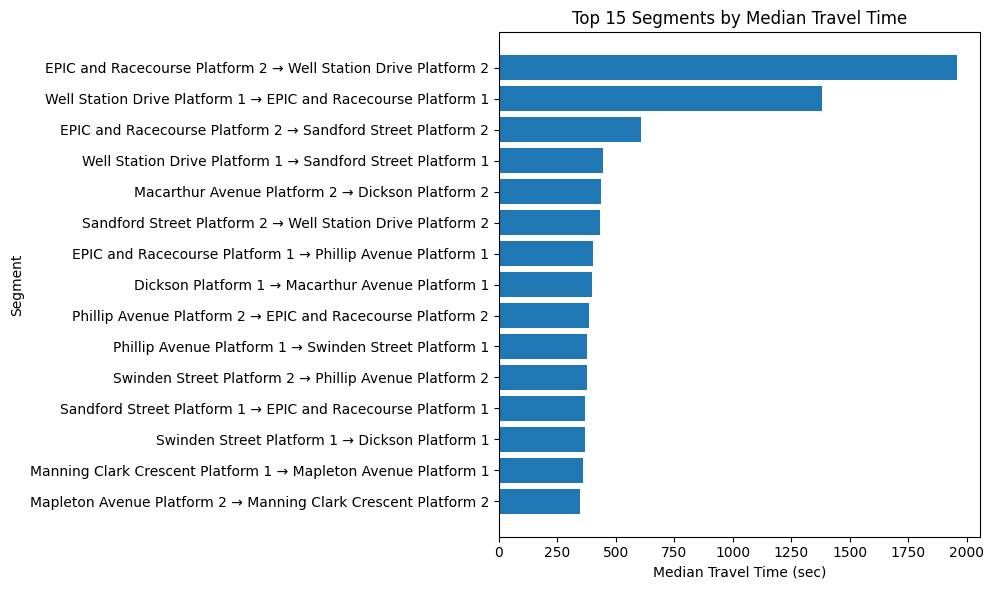

In [212]:
top_segments = segment_summary.head(15)
plt.figure(figsize=(10,6))
plt.barh(top_segments.index.astype(str), top_segments["median"])
plt.xlabel("Median Travel Time (sec)")
plt.ylabel("Segment")
plt.title("Top 15 Segments by Median Travel Time")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation**

The segment-level statistics show that travel times vary across different station pairs, reflecting differences in distance between stations, operational conditions, and passenger activity.

Segments such as Well Station Drive Platform 1 → EPIC and Racecourse Platform 1 and EPIC and Racecourse Platform 2 → Well Station Drive Platform 2 exhibit the highest average travel times, with mean values of 140.31 seconds and 128.69 seconds, respectively. These segments also show relatively high variability (standard deviations of 71.15 and 83.43 seconds), which may indicate longer distances between stations or more variability in operational conditions.

In contrast, segments like Ipima Street Platform 1 → Elouera Street Platform 1 and Mapleton Avenue Platform 1 → Nullarbor Avenue Platform 1 have lower average travel times, with mean values of 56.50 seconds and 57.08 seconds, suggesting shorter distances or more consistent travel conditions between these stations.

Some segments with a large number of observations, such as EPIC and Racecourse Platform 2 → Sandford Street Platform 2 (176,168 records) and Macarthur Avenue Platform 2 → Dickson Platform 2 (87,584 records), provide more stable estimates of average travel time. These segments show mean travel times of 93.29 seconds and 82.34 seconds, respectively, indicating moderate travel durations with relatively consistent variability.

Overall, the results demonstrate that travel time patterns differ across station segments, highlighting the importance of incorporating segment-level spatial relationships when modeling transit travel times. These differences justify the use of spatial modeling approaches, such as graph-based methods, to capture the varying characteristics of each segment in the network.

#### **Weather**



In [213]:
weather_cols = [
    "temperature_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "windspeed_10m",
    "windgusts_10m",
    "total_travel_time_sec"
]

corr = df[weather_cols].corr(numeric_only=True)

corr["total_travel_time_sec"].sort_values(ascending=False)

total_travel_time_sec    1.000000
windgusts_10m            0.048815
windspeed_10m            0.021915
temperature_2m           0.018309
apparent_temperature     0.015513
rain                     0.008193
precipitation            0.008193
snowfall                 0.000717
Name: total_travel_time_sec, dtype: float64

**Interpretation**

The correlation results show that weather-related variables have very weak relationships with total travel time. Among the variables, wind gust speed (windgusts_10m) has the highest correlation with total travel time at 0.0488, followed by wind speed (windspeed_10m) at 0.0219. However, these values are still very close to zero, indicating a negligible linear relationship.

Temperature-related variables, including temperature (temperature_2m, 0.0183) and apparent temperature (apparent_temperature, 0.0155), also show minimal correlation with travel time. Similarly, rain and precipitation (0.0082) have extremely small correlation values, while snowfall (0.0007) shows almost no relationship at all with travel time.

Overall, the results suggest that weather conditions have little direct linear influence on total travel time in the dataset. This may be because the transit system operates on dedicated rail infrastructure, which is less affected by road traffic or moderate weather changes. Nevertheless, weather variables are still included in the model to capture potential nonlinear or indirect effects, which advanced models such as MAGNN-LSTM may learn even when simple correlation analysis shows weak relationships.

#### **Delay**

In [214]:
delay_df = eda[["arrivalDelay", "departureDelay", "total_travel_time_sec"]].copy()

delay_df["delay_group"] = pd.cut(
    delay_df["departureDelay"],
    bins=[-np.inf, -1, 60, np.inf],
    labels=["Early", "On-time / Slight Delay", "Heavy Delay"]
)

delay_summary = (
    delay_df.groupby("delay_group")["total_travel_time_sec"]
    .agg(["count", "mean", "median", "std"])
)

delay_summary

,count,mean,median,std
delay_group,,,,
Early,1414228,382.970672,345.0,220.224643
On-time / Slight Delay,2292301,332.120851,315.0,151.994181
Heavy Delay,282728,328.319717,309.0,157.773029


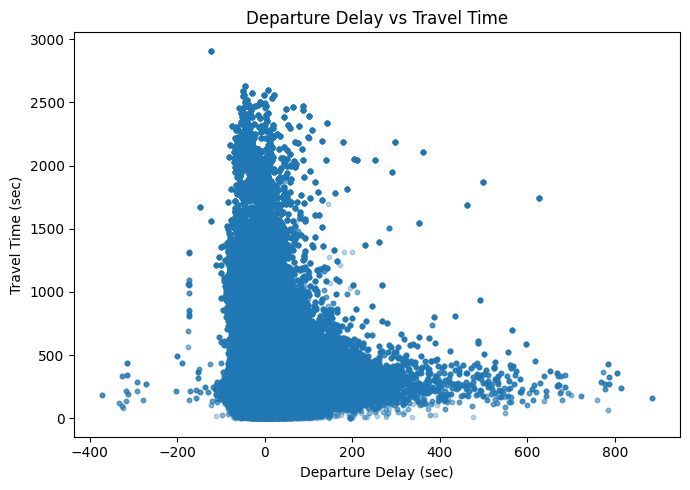

In [215]:
scatter_df = eda[["departureDelay", "total_travel_time_sec"]].dropna().copy()

if len(scatter_df) > 3989555:
    scatter_df = scatter_df.sample(3989555, random_state=42)

plt.figure(figsize=(7,5))
plt.scatter(scatter_df["departureDelay"], scatter_df["total_travel_time_sec"], alpha=0.3, s=10)
plt.xlabel("Departure Delay (sec)")
plt.ylabel("Travel Time (sec)")
plt.title("Departure Delay vs Travel Time")
plt.tight_layout()
plt.show()

**Interpretation**

The statistics show how total travel time varies depending on the level of departure delay. Trips categorized as Early have the highest average total travel time, with a mean of 382.97 seconds and a median of 345 seconds. This group also exhibits the largest variability (standard deviation of 220.22 seconds), indicating that travel times for early departures tend to be more inconsistent.

Trips classified as On-time / Slight Delay represent the largest portion of the dataset (2,292,301 records). These trips have an average travel time of 332.12 seconds and a median of 315 seconds, with a relatively lower standard deviation of 151.99 seconds, suggesting more stable and predictable travel times under normal operating conditions.

Interestingly, trips with Heavy Delay have a slightly lower mean travel time (328.32 seconds) compared to the on-time group, with a median of 309 seconds and a standard deviation of 157.77 seconds. This pattern may indicate that heavy delays are often related to schedule deviations or dwell times at stations rather than longer segment travel times, meaning that once the vehicle resumes movement, the travel time between segments may remain relatively similar.

Overall, the results suggest that departure delay categories do not necessarily correspond to longer segment travel times, highlighting that delays in transit systems may arise from factors such as station dwell time, operational scheduling, or passenger boarding, rather than purely slower movement between stations.

#### **Slowdown vs No Slowdown**

In [217]:
df.drop(df[df["total_travel_time_sec"] == 86364.0].index, inplace=True)

In [218]:
slowdown_summary = (
    df.groupby("is_slowdown")["total_travel_time_sec"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

slowdown_summary.rename(index={0: "No Slowdown", 1: "Slowdown"})

,count,mean,median,std,min,max
is_slowdown,,,,,,
No Slowdown,2004202,330.561539,312.0,159.670314,0.0,2909.0
Slowdown,1985353,369.413356,335.0,198.855699,0.0,2909.0


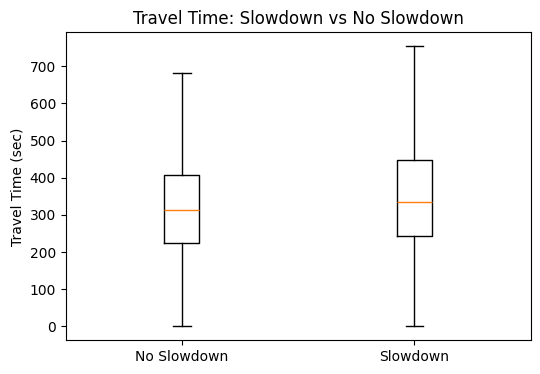

In [219]:
sample = df[["is_slowdown", "total_travel_time_sec"]].dropna()

if len(sample) > 3989555:
    sample = sample.sample(3989555, random_state=42)

groups = [
    sample[sample["is_slowdown"] == 0]["total_travel_time_sec"],
    sample[sample["is_slowdown"] == 1]["total_travel_time_sec"]
]

plt.figure(figsize=(6,4))
plt.boxplot(groups, tick_labels=["No Slowdown", "Slowdown"], showfliers=False)
plt.ylabel("Travel Time (sec)")
plt.title("Travel Time: Slowdown vs No Slowdown")
plt.show()

**Interpretation**

The statistics indicate a clear difference in total travel time between trips with and without slowdown events. Trips classified as No Slowdown have a mean total travel time of 330.56 seconds and a median of 312 seconds, with a standard deviation of 159.67 seconds, suggesting relatively shorter and more consistent travel times when vehicles maintain normal operating speeds.

In contrast, trips labeled as Slowdown have a higher mean travel time of 369.41 seconds and a median of 335 seconds, indicating that slowdown events are associated with longer travel durations. The higher standard deviation (198.86 seconds) also suggests greater variability in travel times when slowdowns occur, meaning that trips experiencing slowdowns tend to be less predictable.

Both categories share the same maximum travel time of 2909 seconds, indicating that extreme travel durations can occur regardless of slowdown classification. However, the higher mean and variability observed in the slowdown group suggest that slowdown events contribute to increased travel time and operational variability.

Overall, these findings highlight that slowdown conditions have a noticeable impact on transit travel time, supporting the inclusion of slowdown-related features in predictive models to better capture disruptions and variations in vehicle movement.

# **Visualization**

In [220]:
stations = [
    {"name": "Gungahlin Place", "lat": -35.185639, "lon": 149.135481},
    {"name": "Manning Clark North", "lat": -35.1869861, "lon": 149.1433722},
    {"name": "Mapleton Avenue", "lat": -35.193389, "lon": 149.150972},
    {"name": "Nullarbor Avenue", "lat": -35.200556, "lon": 149.149305},
    {"name": "Well Station Drive", "lat": -35.2091361, "lon": 149.1472889},
    {"name": "Sandford Street", "lat": -35.221703, "lon": 149.144722},
    {"name": "EPIC & Racecourse", "lat": -35.228438, "lon": 149.143558},
    {"name": "Phillip Avenue", "lat": -35.235895, "lon": 149.143757},
    {"name": "Swinden Street", "lat": -35.2445364, "lon": 149.1344672},
    {"name": "Dickson Interchange", "lat": -35.2505862, "lon": 149.1336686},
    {"name": "Macarthur Avenue", "lat": -35.259988 , "lon": 149.132039},
    {"name": "Ipima Street", "lat": -35.265918, "lon": 149.131244},
    {"name": "Elouera Street", "lat": -35.272761, "lon": 149.130168},
    {"name": "Alinga Street", "lat": -35.277930, "lon": 149.129330}
]

### **Trips along the line**

/Users/joehannacansino/.pyenv/versions/3.11.10/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


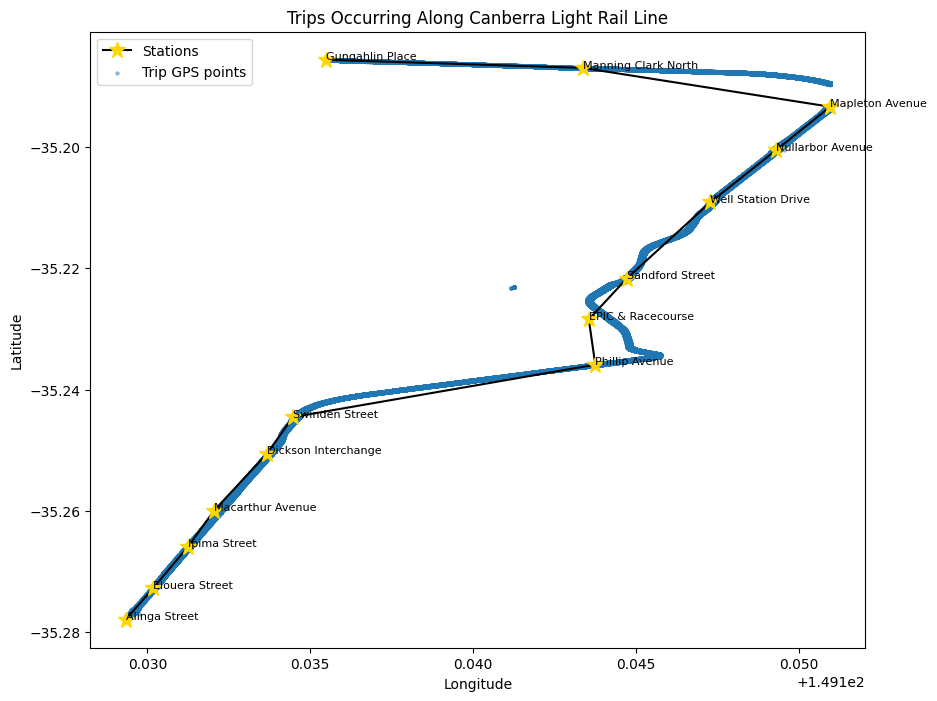

In [221]:
lats = [s["lat"] for s in stations]
lons = [s["lon"] for s in stations]
names = [s["name"] for s in stations]

lat_min, lat_max = min(lats), max(lats)
lon_min, lon_max = min(lons), max(lons)

map_trips = df[
    (df["latitude"] >= lat_min) &
    (df["latitude"] <= lat_max) &
    (df["longitude"] >= lon_min) &
    (df["longitude"] <= lon_max)
]

plt.figure(figsize=(10,8))

plt.plot(
    lons, lats,
    linestyle='-',
    marker='*',
    color='black',
    markerfacecolor='gold',
    markeredgecolor='gold',
    markersize=12,
    label="Stations"
)

for i, name in enumerate(names):
    plt.text(lons[i], lats[i], name, fontsize=8)

plt.scatter(
    map_trips["longitude"],
    map_trips["latitude"],
    s=5,
    alpha=0.4,
    label="Trip GPS points"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Trips Occurring Along Canberra Light Rail Line")
plt.legend()
plt.show()

### **Trips along the line (Peak vs Off-Peak)**

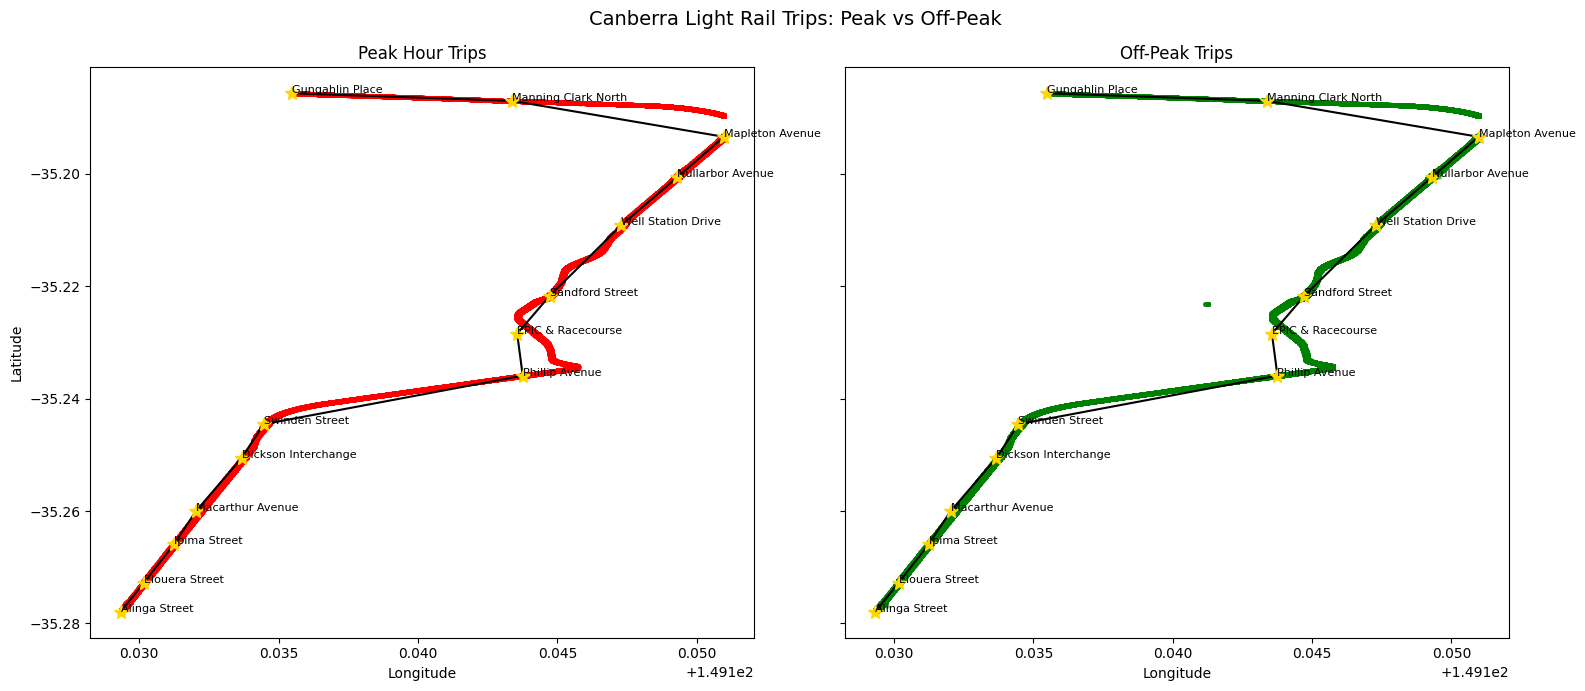

In [222]:
lats = [s["lat"] for s in stations]
lons = [s["lon"] for s in stations]
names = [s["name"] for s in stations]

lat_min, lat_max = min(lats), max(lats)
lon_min, lon_max = min(lons), max(lons)

map_trips = df[
    (df["latitude"] >= lat_min) &
    (df["latitude"] <= lat_max) &
    (df["longitude"] >= lon_min) &
    (df["longitude"] <= lon_max)
].copy()

peak_trips = map_trips[map_trips["is_peak_hour"] == 1]
offpeak_trips = map_trips[map_trips["is_peak_hour"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(16,7), sharex=True, sharey=True)


axes[0].plot(
    lons, lats,
    linestyle='-',
    marker='*',
    color='black',
    markerfacecolor='gold',
    markeredgecolor='gold',
    markersize=10
)

axes[0].scatter(
    peak_trips["longitude"],
    peak_trips["latitude"],
    s=6,
    alpha=0.4,
    color="red"
)

for i, name in enumerate(names):
    axes[0].text(lons[i], lats[i], name, fontsize=8)

axes[0].set_title("Peak Hour Trips")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")


axes[1].plot(
    lons, lats,
    linestyle='-',
    marker='*',
    color='black',
    markerfacecolor='gold',
    markeredgecolor='gold',
    markersize=10
)

axes[1].scatter(
    offpeak_trips["longitude"],
    offpeak_trips["latitude"],
    s=6,
    alpha=0.4,
    color="green"
)

for i, name in enumerate(names):
    axes[1].text(lons[i], lats[i], name, fontsize=8)

axes[1].set_title("Off-Peak Trips")
axes[1].set_xlabel("Longitude")

plt.suptitle("Canberra Light Rail Trips: Peak vs Off-Peak", fontsize=14)
plt.tight_layout()
plt.show()

### **Trips along the line (Slowdown vs No-slowdown)**

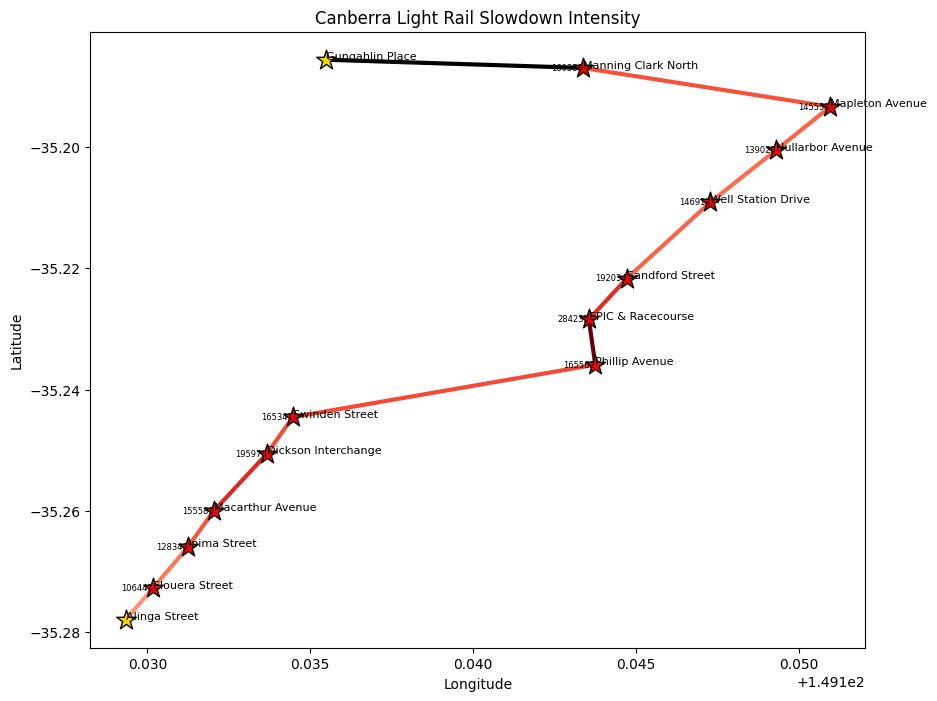

In [223]:
def clean_station(text):
    if pd.isna(text):
        return text
    
    text = str(text)
    text = re.sub(r"Platform \d+", "", text)
    text = text.split("→")[0].strip()

    text = text.replace("Manning Clark Crescent", "Manning Clark North")
    text = text.replace("Dickson", "Dickson Interchange")
    text = text.replace("EPIC and Racecourse", "EPIC & Racecourse")

    return text.strip()


slow_df = df[df["is_slowdown"] == 1].copy()
slow_df["origin_clean"] = slow_df["segment"].apply(clean_station)


slow_counts = slow_df["origin_clean"].value_counts().to_dict()

max_count = max(slow_counts.values()) if slow_counts else 1
norm = mcolors.Normalize(vmin=0, vmax=max_count)
cmap = cm.Reds


plt.figure(figsize=(10,8))

for i in range(len(stations)-1):

    s1 = stations[i]["name"]
    s2 = stations[i+1]["name"]

    lat1, lon1 = stations[i]["lat"], stations[i]["lon"]
    lat2, lon2 = stations[i+1]["lat"], stations[i+1]["lon"]

    count = slow_counts.get(s1, 0)

    if count == 0:
        color = "black"
    else:
        color = cmap(norm(count))

    plt.plot([lon1, lon2], [lat1, lat2], color=color, linewidth=3)

for s in stations:

    count = slow_counts.get(s["name"], 0)
    star_color = "gold" if count == 0 else "red"

    plt.scatter(
        s["lon"],
        s["lat"],
        marker="*",
        s=220,
        color=star_color,
        edgecolor="black",
        zorder=3
    )

    plt.text(s["lon"], s["lat"], s["name"], fontsize=8)

    if count > 0:
        plt.text(
            s["lon"],
            s["lat"] - 0.0007,
            f"{count}",
            fontsize=6,
            color="black",
            ha="right",
            va="bottom"
        )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Canberra Light Rail Slowdown Intensity")
plt.show()

**Interpretation**

Black → no slowdowns

Light red → few slowdowns

Dark red → frequent slowdowns